# Customer Churn Prediction using XGBoost

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis
6. Key Findings
7. Feature Engineering
8. Model Building
9. Model Evaluation
10. Save Model
11. Streamlit Application (we'll add this later)
12. Conclusion

## Project Objective

Build an XGBoost model to predict telecom customer churn using customer demographics and service information. The project includes EDA, feature engineering, model training, and deployment using Streamlit.

# EDA TO GET BUISNESS INSIGHTS

In [3]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('customer_churn.csv')

df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# investigating total charges

df["TotalCharges"].dtype

dtype('O')

In [10]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [11]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df1 = df.copy()
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df1 = df1[df1["TotalCharges"] != " "]

In [14]:
df1["TotalCharges"] = pd.to_numeric(df1["TotalCharges"])

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [16]:
df1.duplicated().sum()

np.int64(0)

In [17]:
df1.nunique()

customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [18]:
df1["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [19]:
df1["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

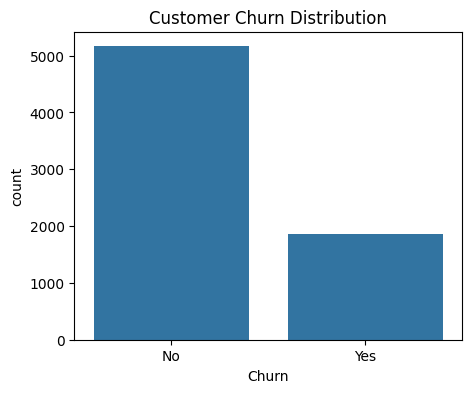

In [20]:
plt.figure(figsize=(5,4))

sns.countplot(x="Churn", data=df1)

plt.title("Customer Churn Distribution")
plt.show()

# inspecting contract feature

In [21]:
pd.crosstab(df1["Contract"], df1["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [22]:
pd.crosstab(df1["Contract"], df1["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


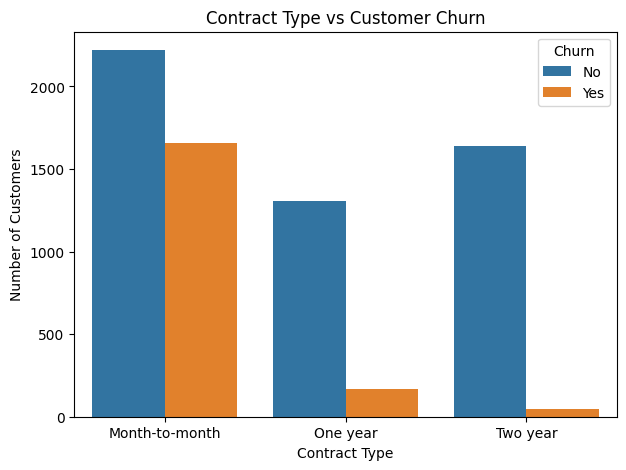

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(x="Contract", hue="Churn", data=df1)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Customers with month-to-month contracts exhibit the highest churn rate (42.7%), whereas customers with two-year contracts rarely churn (2.8%). This suggests contract duration is a strong indicator of customer retention.

# inspecting tenure feature

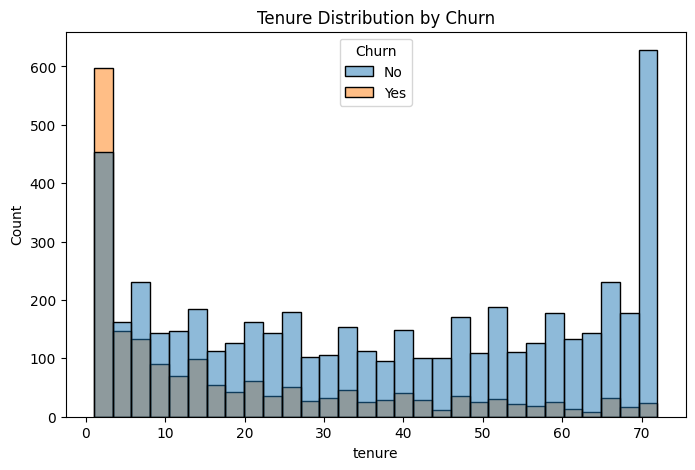

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data=df1, x="tenure", hue="Churn", bins=30)

plt.title("Tenure Distribution by Churn")
plt.show()

In [25]:
df1.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


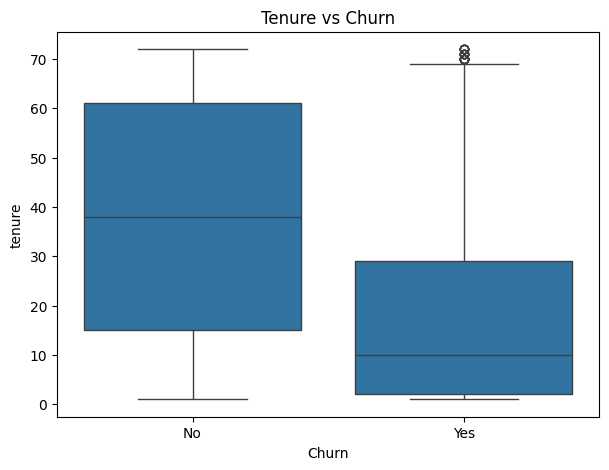

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="tenure", data=df1)

plt.title("Tenure vs Churn")
plt.show()

Customers with shorter tenure exhibit a much higher churn rate compared to long-term customers. The majority of churn occurs within the first few months of service, while customers with higher tenure are more likely to remain with the company. This indicates that tenure is a strong predictor of customer churn.

# inspecting monthly charges feature

In [27]:
df1.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


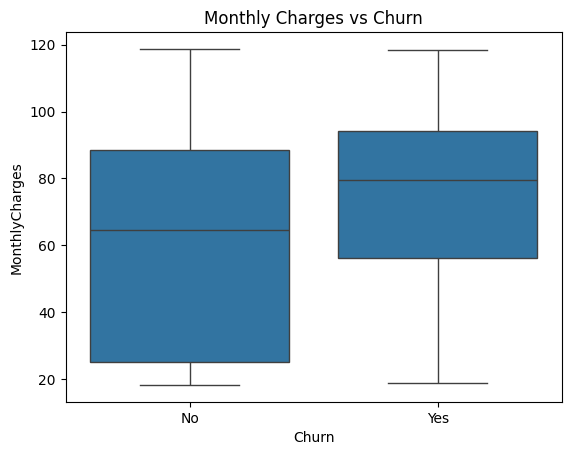

In [28]:
plt.Figure(figsize=(7,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df1)

plt.title("Monthly Charges vs Churn")
plt.show()

Customers who churn tend to have higher monthly charges than customers who stay. The median monthly charge for churned customers is ₹79.65, compared to ₹64.45 for retained customers. This indicates that higher monthly charges are associated with an increased likelihood of churn, making MonthlyCharges an important feature for churn prediction.

# inspecting Internet Service

In [30]:
pd.crosstab(
    df1["InternetService"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


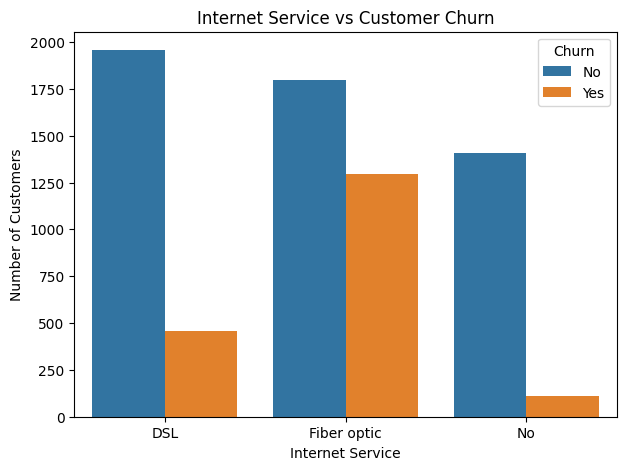

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df1
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

Internet service type has a strong relationship with customer churn. Customers using Fiber Optic internet exhibit the highest churn rate (41.9%), whereas customers without internet service have the lowest churn rate (7.4%). This suggests that InternetService is an important predictor of customer churn.

# inspecting payment method

In [33]:
pd.crosstab(
    df1["PaymentMethod"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


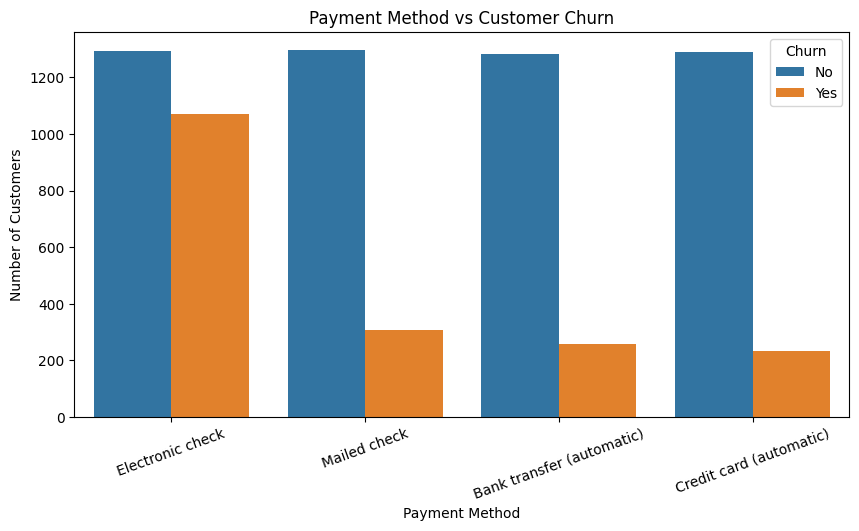

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df1
)

plt.xticks(rotation=20)
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.show()

Customers using Electronic Check exhibit the highest churn rate (45.3%), whereas customers using automatic payment methods such as Credit Card and Bank Transfer have significantly lower churn rates (around 15–17%). This suggests that payment method is an important factor associated with customer retention.

# inspecting Online Security

In [35]:
pd.crosstab(
    df1["OnlineSecurity"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


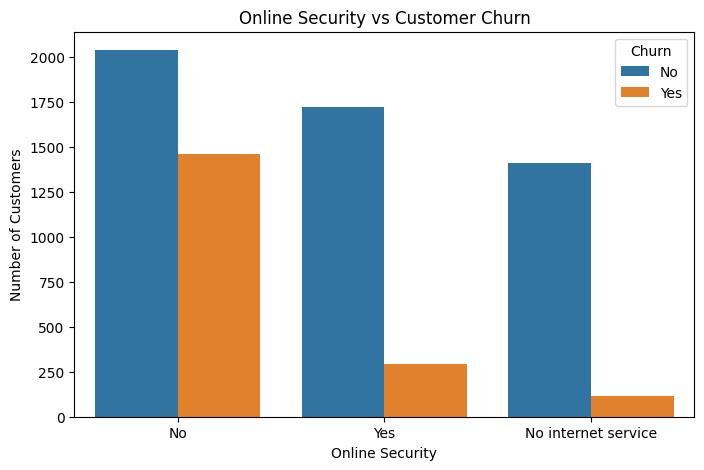

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="OnlineSecurity",
    hue="Churn",
    data=df1
)

plt.title("Online Security vs Customer Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

Customers without Online Security exhibit a significantly higher churn rate (41.8%) compared to customers who subscribe to Online Security (14.6%). This suggests that customers who adopt additional value-added services are more likely to remain with the company, making OnlineSecurity an important predictor of customer churn.

# inspecting TechSupport

In [37]:
pd.crosstab(
    df1["TechSupport"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


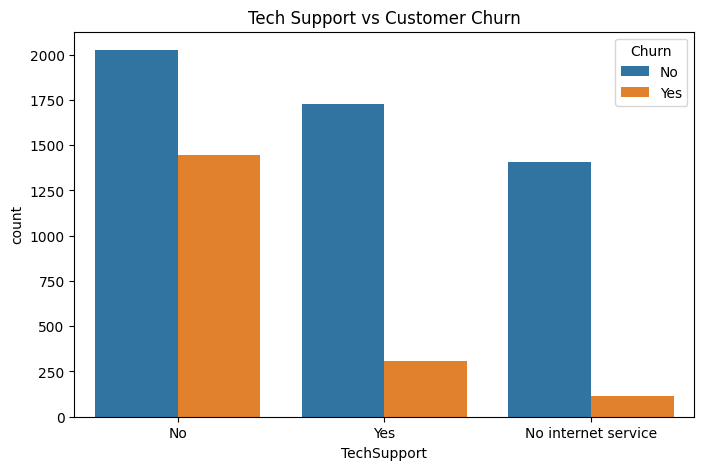

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=df1
)

plt.title("Tech Support vs Customer Churn")
plt.show()

Customers without Tech Support exhibit a significantly higher churn rate (41.6%) compared to customers who subscribe to Tech Support (15.2%). This indicates that value-added customer support services are strongly associated with improved customer retention, making TechSupport an important feature for churn prediction.

# Key Findings

### 1. Contract Type
- Customers with **month-to-month contracts** have the highest churn rate (**42.7%**).
- Customers with **two-year contracts** have the lowest churn rate (**2.8%**).
- Contract duration appears to be a strong predictor of customer churn.

### 2. Tenure
- Customers with **shorter tenure** are more likely to churn.
- Median tenure:
  - Churned customers: **10 months**
  - Retained customers: **38 months**

### 3. Monthly Charges
- Customers who churn pay **higher monthly charges**.
- Median Monthly Charges:
  - Churned customers: **₹79.65**
  - Retained customers: **₹64.45**

### 4. Internet Service
- **Fiber Optic** customers have the highest churn rate (**41.9%**).
- Customers with **no internet service** have the lowest churn rate (**7.4%**).

### 5. Payment Method
- Customers using **Electronic Check** have the highest churn rate (**45.3%**).
- Customers using **automatic payment methods** (Credit Card and Bank Transfer) have significantly lower churn rates.

### 6. Online Security
- Customers **without Online Security** have a churn rate of **41.8%**.
- Customers **with Online Security** have a churn rate of only **14.6%**.

### 7. Tech Support
- Customers **without Tech Support** have a churn rate of **41.6%**.
- Customers **with Tech Support** have a churn rate of only **15.2%**.